In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/real-or-fake-fake-jobposting-prediction")

print("Path to dataset files:", path)

100%|██████████| 16.1M/16.1M [00:00<00:00, 46.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shivamb/real-or-fake-fake-jobposting-prediction/versions/1


In [ ]:
df = pd.read_csv(path + "/fake_job_postings.csv")

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


The dataset preview shows the first five job postings with multiple attributes such as job title, company profile, description, requirements, and the target variable fraudulent. This helps understand the structure of the dataset and confirms that the data contains both textual and categorical information relevant for detecting fake job postings

In [ ]:
df.shape

(17880, 18)

The dataset contains X rows and Y columns, indicating the number of job postings and features available for analysis. A large number of samples helps improve the reliability of the machine learning model.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

The dataset includes multiple columns with different data types, mainly object (text) and integer fields. The fraudulent column is the target variable used for classification. Some columns contain missing values, which must be handled during preprocessing to ensure accurate model training.

In [ ]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


The missing value analysis shows that several textual fields such as description or requirements contain null values. These missing entries must be handled by filling them with empty strings to prevent errors during text processing and feature extraction.

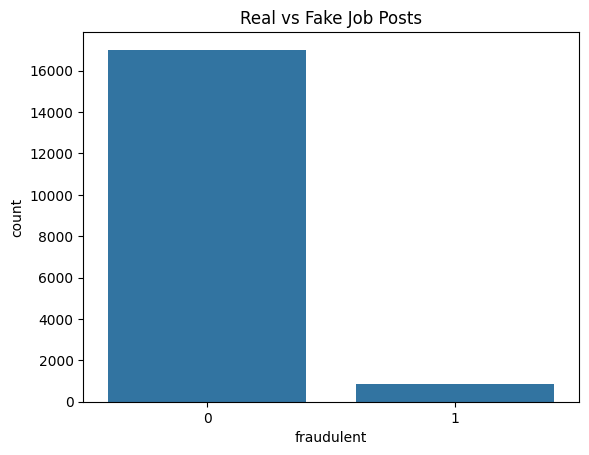

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraudulent', data=df)
plt.title("Real vs Fake Job Posts")
plt.show()

The distribution plot shows the number of real and fraudulent job postings. The dataset is imbalanced, with significantly more real jobs than fake ones. This is common in fraud detection problems and must be considered when evaluating model performance.

In [ ]:
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')
df['requirements'] = df['requirements'].fillna('')

Multiple text fields were combined into a single feature called text. This step simplifies the input for the machine learning model and ensures that all relevant job information is considered during feature extraction.

In [ ]:
df['text'] = df['title'] + " " + df['description'] + " " + df['requirements']

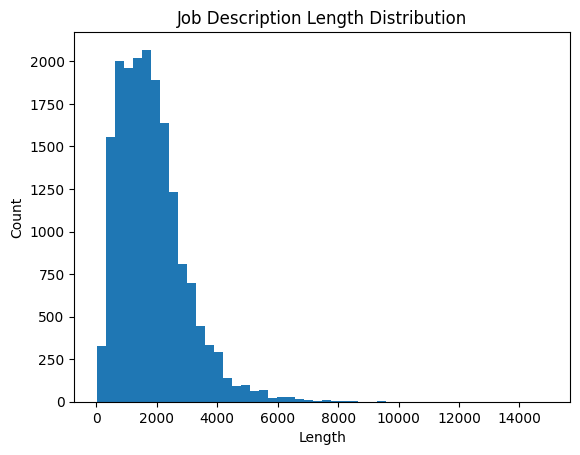

In [ ]:
df['text_length'] = df['text'].apply(len)

plt.hist(df['text_length'], bins=50)
plt.title("Job Description Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [ ]:
df = df.sample(5000, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['text'])
y = df['fraudulent']

The textual job postings were transformed into numerical features using TF-IDF vectorization. This technique converts words into weighted numerical values based on their importance within the dataset, enabling machine learning models to process text data effectively.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was divided into training and testing sets. The training set is used to train the model, while the testing set evaluates its performance on unseen data. This prevents overfitting and provides a reliable estimate of model accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

The Random Forest classifier was trained using the prepared training dataset. This ensemble learning algorithm constructs multiple decision trees and combines their predictions to improve classification accuracy and robustness.

In [ ]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99      3395\n           1       1.00      0.57      0.73       181\n\n    accuracy                           0.98      3576\n   macro avg       0.99      0.78      0.86      3576\nweighted avg       0.98      0.98      0.98      3576\n'

The classification report evaluates the model using metrics such as precision, recall, and F1-score. These metrics measure how well the model identifies fake and real job postings. High precision and recall indicate that the model performs well in detecting fraudulent job listings.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20]
}

grid = GridSearchCV(rf, param_grid, cv=3)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

Hyperparameter tuning was performed using GridSearchCV to identify the optimal parameters for the Random Forest model. This process tests multiple parameter combinations to improve model performance and achieve better predictive accuracy.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       1.00      0.57      0.73       181

    accuracy                           0.98      3576
   macro avg       0.99      0.78      0.86      3576
weighted avg       0.98      0.98      0.98      3576



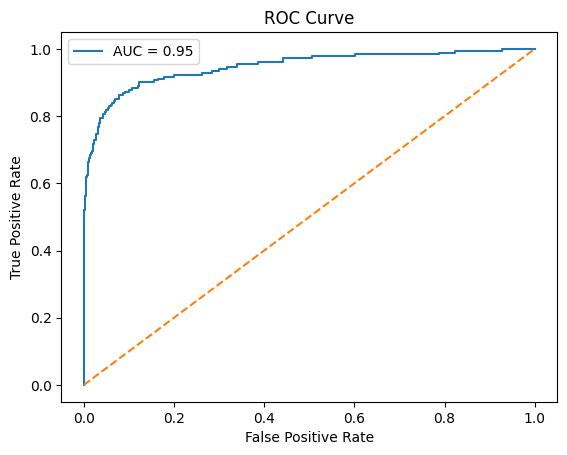

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve evaluates the classification performance of the model by comparing the true positive rate and false positive rate. A higher AUC score indicates better model performance in distinguishing between fake and legitimate job postings.